# Open Data Exploration: Hippocampus, Entorhinal Cortex, and NWB

In this tutorial, we will use an open DANDI dataset to connect behavior, spikes, and LFP. You will stream an NWB file, inspect its contents, and begin asking how neural activity relates to position and rhythmic brain activity.

This first section sets up plotting and streams one NWB file from DANDI without downloading the full dataset.

## 0. Colab Setup

Run this once at the start. It installs the packages needed to talk to DANDI, read NWB files, stream remote HDF5 content, and make consistent plots.

In [3]:
import importlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PACKAGE_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "pillow": "PIL",
    "seaborn": "seaborn",
    "ipywidgets": "ipywidgets",
    "dandi": "dandi",
    "pynwb": "pynwb",
    "remfile": "remfile",
    "h5py": "h5py",
    "h5glance": "h5glance",
}

failed = {}
for package, import_name in PACKAGE_IMPORTS.items():
    try:
        importlib.import_module(import_name)
    except Exception as exc:
        failed[package] = repr(exc)

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")

if failed:
    print("Installing missing packages into this notebook kernel:", list(failed))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", *failed])
    print("Installed. If imports still fail, restart the runtime and rerun this cell.")
else:
    print("All required packages are available in this notebook kernel.")

Python executable: /home/labuser/miniforge3/envs/camp2026/bin/python
Python version: 3.12.13
All required packages are available in this notebook kernel.


## 1. Plotting Defaults

Use high-resolution inline figures, a color-blind friendly palette, and Seaborn's `talk` context so plots are easy to read.

In [ ]:
%config InlineBackend.figure_format = "retina"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    context="talk",
    style="ticks",
    palette="colorblind",
    rc={
        "figure.figsize": (8, 5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "savefig.bbox": "tight",
    },
)

PALETTE = sns.color_palette("colorblind")
COLORS = {
    "blue": PALETTE[0],
    "orange": PALETTE[1],
    "green": PALETTE[2],
    "red": PALETTE[3],
    "purple": PALETTE[4],
    "brown": PALETTE[5],
    "pink": PALETTE[6],
    "gray": PALETTE[7],
}

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)

sns.palplot(PALETTE)

## 2. Stream the HPC-Entorhinal Dataset from DANDI

We will use Dandiset `001701`, which contains mouse medial entorhinal cortex and hippocampal recordings during spatial behavior. The useful point for this tutorial is that individual NWB files can contain behavior, spike times, head direction, and LFP.

We will first ask DANDI what files exist, then choose one file to stream. Streaming means we open a remote NWB file and read pieces as needed instead of downloading the full dataset.

In [5]:
from dandi.dandiapi import DandiAPIClient

DANDISET_ID = "001701"
DANDISET_VERSION = "0.260120.0303"

client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)

assets = list(dandiset.get_assets())
asset_table = pd.DataFrame(
    [
        {
            "path": asset.path,
            "asset_id": asset.identifier,
            "size_mb": asset.size / 1_000_000,
        }
        for asset in assets
        if asset.path.endswith(".nwb")
    ]
)

asset_table["subject"] = asset_table["path"].str.extract(r"sub-([^/]+)")
asset_table["session"] = asset_table["path"].str.extract(r"ses-([^_]+)")
asset_table = asset_table.sort_values(["subject", "path"]).reset_index(drop=True)

DATASET_TITLE = "Aery Jones et al. (2026): Entorhinal cortex represents task-relevant remote locations independent of CA1"
DATASET_DESCRIPTION = (
    "Neuropixels recordings from medial entorhinal cortex and hippocampus "
    "while mice performed a spatial match-to-sample task. Files can include "
    "position, head direction, spike times, electrode metadata, and LFP."
)

subject_summary = (
    asset_table.groupby("subject", as_index=False)
    .agg(
        n_files=("path", "count"),
        total_size_mb=("size_mb", "sum"),
        min_file_mb=("size_mb", "min"),
        max_file_mb=("size_mb", "max"),
    )
    .sort_values("subject")
)

dataset_summary = pd.DataFrame(
    {
        "field": ["Dandiset", "Version", "Title", "Description", "Animals", "NWB files", "Total size (GB)"],
        "value": [
            DANDISET_ID,
            DANDISET_VERSION,
            DATASET_TITLE,
            DATASET_DESCRIPTION,
            subject_summary.shape[0],
            len(asset_table),
            asset_table["size_mb"].sum() / 1000,
        ],
    }
)

display(dataset_summary)
display(subject_summary.round(2))

,field,value
0,Dandiset,001701
1,Version,0.260120.0303
2,Title,Aery Jones et al. (2026): Entorhinal cortex re...
3,Description,Neuropixels recordings from medial entorhinal ...
4,Animals,12
5,NWB files,218
6,Total size (GB),6.231885


,subject,n_files,total_size_mb,min_file_mb,max_file_mb
0,AppleBottom,20,576.35,18.70,41.92
1,BaggySweatpants,19,452.89,12.97,43.74
2,Curie,19,696.44,19.08,62.02
3,Franklin,20,744.86,16.24,104.33
4,Lamarr,19,775.70,20.05,87.99
5,Lovelace,19,634.51,23.34,48.73
6,Noether,20,557.90,21.72,43.64
7,Payne,19,469.69,17.98,39.25
8,StickPin,19,380.10,14.69,30.76
9,StrappyReeboks,19,389.14,14.92,26.11


### Choose an Animal and File

Start by choosing one animal. The table below updates to show that animal's NWB files; then choose one file to stream.

In [6]:
import ipywidgets as widgets
from IPython.display import clear_output, display

subjects = sorted(asset_table["subject"].dropna().unique())

subject_dropdown = widgets.Dropdown(
    options=subjects,
    value=subjects[0],
    description="Subject:",
    style={"description_width": "initial"},
)

file_dropdown = widgets.Dropdown(
    options=[],
    description="NWB file:",
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)
file_table_output = widgets.Output()

def update_file_options(*_):
    rows = asset_table.query("subject == @subject_dropdown.value").copy()
    options = [
        (f"{row.session} | {row.size_mb:.1f} MB", row.path)
        for row in rows.itertuples()
    ]
    file_dropdown.options = options
    if options:
        file_dropdown.value = options[0][1]

    with file_table_output:
        clear_output(wait=True)
        display(rows[["session", "size_mb", "path"]].round({"size_mb": 2}))

subject_dropdown.observe(update_file_options, names="value")
update_file_options()

display(widgets.VBox([subject_dropdown, file_table_output, file_dropdown]))

### Open the Selected NWB File

The two important pieces are:

1. DANDI gives us a temporary URL for the selected asset.
2. `remfile` and `pynwb` let us open that remote NWB file as if it were local.

Keep the `io` object open while using `nwb`; closing it closes the remote file handle.

In [54]:
import h5py
import remfile
from pynwb import NWBHDF5IO

def stream_nwb_from_dandi(asset_path):
    """Open one DANDI NWB asset for streaming and return the NWB object.

    This deliberately keeps the mechanics visible: asset path -> signed content URL
    -> remote file handle -> PyNWB reader -> NWBFile.
    """
    asset = dandiset.get_asset_by_path(asset_path)
    stream_url = asset.get_content_url(follow_redirects=1)
    remote_file = remfile.File(stream_url)
    h5_file = h5py.File(remote_file, mode="r")
    io = NWBHDF5IO(file=h5_file, mode="r", load_namespaces=False)
    nwb = io.read()
    return nwb, io, h5_file, remote_file, asset

selected_path = file_dropdown.value
print(f"Streaming: {selected_path}")

# If you re-run this cell, close the previous stream first.
if "io" in globals():
    try:
        io.close()
    except Exception:
        pass
if "h5_file" in globals():
    try:
        h5_file.close()
    except Exception:
        pass
if "remote_file" in globals():
    try:
        remote_file.close()
    except Exception:
        pass

nwb, io, h5_file, remote_file, selected_asset = stream_nwb_from_dandi(selected_path)
nwb

Streaming: sub-Curie/sub-Curie_ses-Curie-DY01-g1_behavior+ecephys.nwb


Data type,float64
Shape,"(142977,)"
Array size,1.09 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),1143816
Compressed size (bytes),1143816
Compression ratio,1.0
Data type,float64
Shape,"(142977, 2)"


### Quick Inventory

Before analyzing anything, ask what the file contains. This is the basic open-data habit: inspect first, analyze second.

In [55]:
def summarize_nwb(nwb):
    unit_count = len(nwb.units) if nwb.units is not None else 0

    summary = pd.DataFrame(
        {
            "field": [
                "session_description",
                "identifier",
                "units",
                "acquisition keys",
                "processing modules",
                "interval tables",
            ],
            "value": [
                nwb.session_description,
                nwb.identifier,
                unit_count,
                list(nwb.acquisition.keys()),
                list(nwb.processing.keys()),
                list(nwb.intervals.keys()),
            ],
        }
    )
    return summary

display(summarize_nwb(nwb))

if nwb.units is not None:
    print("Unit-table columns:")
    print(list(nwb.units.colnames))

,field,value
0,session_description,X Maze
1,identifier,"AeryJones,EmilyCurieDY01-g1"
2,units,341
3,acquisition keys,[]
4,processing modules,"[behavior, probe_0_channel_308, probe_1_channe..."
5,interval tables,[]


Unit-table columns:
['spike_times', 'electrodes', 'electrode_group']


### Explore the NWB File Structure

`h5glance` is a lightweight browser for HDF5 files, the storage format used by NWB. Open a few groups such as `/processing`, `/units`, and `/general` to see how the file is organized before analyzing it in code.

In [56]:
from h5glance import H5Glance

H5Glance(h5_file)

<remfile.RemFile.RemFile object at 0x7c9ad4d209b0>/ (5 attributes)
├acquisition	(0 children)
├analysis	(0 children)
├file_create_date	[ASCII string: 1]
├general	(8 children)
├identifier	[UTF-8 string: scalar]
├processing	(3 children)
├session_description	[UTF-8 string: scalar]
├session_start_time	[ASCII string: scalar]
├specifications	(3 children)
├stimulus	(2 children)
├timestamps_reference_time	[ASCII string: scalar]
└units	(6 children) (5 attributes)

**Task:** Use the file browser to find where position is stored. Look for a `Position` object and a `SpatialSeries` dataset. The next cell uses the position data stored at `processing/behavior/Position/position`.

## 3. Plot Position

Start by extracting the animal's x and y position. First check the full available time range, then choose a `start_time` and `stop_time` window to extract.

In [57]:
position_series = nwb.processing["behavior"]["Position"]["position"]
position_data = position_series.data[:]

sampling_rate = position_series.rate
series_start_time = position_series.starting_time
time = series_start_time + np.arange(position_data.shape[0]) / sampling_rate

print(f"Full available time range: {time.min():g} to {time.max():g} s")

Full available time range: 4.63713 to 2387.57 s


In [58]:
start_time = 0.0
stop_time = 120.0

In [59]:
time_mask = (time >= start_time) & (time <= stop_time)

position_df = pd.DataFrame(
    {
        "time": time[time_mask],
        "x": position_data[time_mask, 0],
        "y": position_data[time_mask, 1],
    }
)

display(position_df.head())
print(f"Extracted {len(position_df):,} position samples from {start_time:g} to {stop_time:g} s.")

,time,x,y
0,4.637133,10.087373,9.815045
1,4.653800,10.093080,9.828947
2,4.670466,10.098292,9.843419
3,4.687133,10.102616,9.858832
4,4.703800,10.105833,9.875218


Extracted 6,922 position samples from 0 to 120 s.


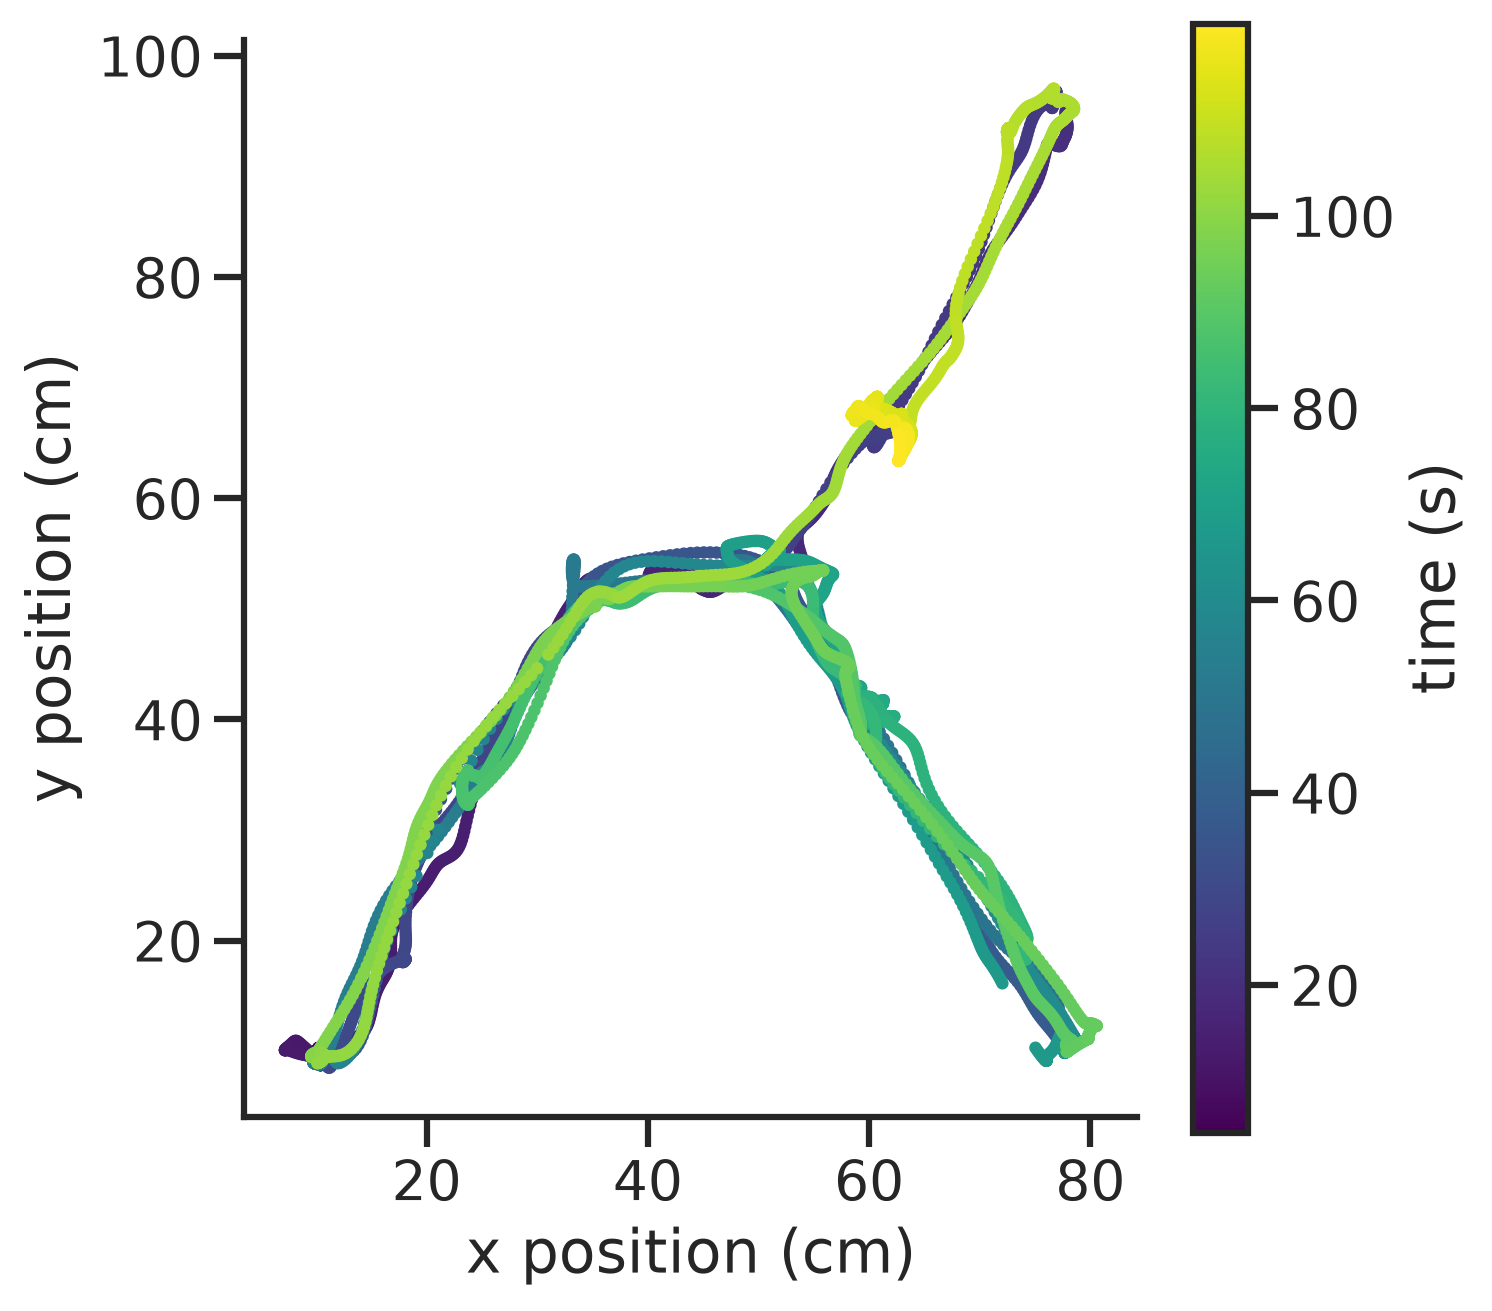

In [60]:
fig, ax = plt.subplots(figsize=(6, 6))

points = ax.scatter(
    position_df["x"],
    position_df["y"],
    c=position_df["time"],
    cmap="viridis",
    s=5,
)

ax.set_xlabel("x position (cm)")
ax.set_ylabel("y position (cm)")
ax.set_aspect("equal")

cbar = fig.colorbar(points, ax=ax)
cbar.set_label("time (s)")

### Challenge: Plot Speed Over Time

The trajectory plot above shows *where* the animal was, but not *how fast* it was moving. Using the same `position_df` (columns `time`, `x`, `y`), compute the animal's speed at each moment and plot speed vs. time over the same `start_time` to `stop_time` window.

Before writing code, think through the problem:

- Speed is not stored directly in the file — what do you have, and what do you need to derive from it?
- Position is sampled at discrete times. How do you turn a sequence of (x, y) points into a distance traveled?
- If you compute something between *consecutive* samples, how many speed values do you end up with compared to the number of position samples? How should you line those values up with a `time` array for plotting?

The scaffold below outlines the steps but leaves the key computation for you to fill in.

In [ ]:
# Challenge: compute and plot speed over time using position_df

# Step 1: Find the displacement between consecutive samples along x and y.
# dx = ...
# dy = ...

# Step 2: Turn (dx, dy) into a single distance per step.

# Step 3: Find the time elapsed between consecutive samples.
# dt = ...

# Step 4: Combine distance and dt into a speed for each step.
# speed = ...

# Step 5: `speed` has one fewer value than position_df has rows, since it
# describes what happened *between* samples. Decide how to pair each speed
# value with a time (e.g. the earlier timestamp, the later one, or the
# midpoint) before plotting.

fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(speed_time, speed)
ax.set_xlabel("time (s)")
ax.set_ylabel("speed (cm/s)")

#### Solution

Try the challenge yourself before running this cell.

Text(0, 0.5, 'speed (cm/s)')

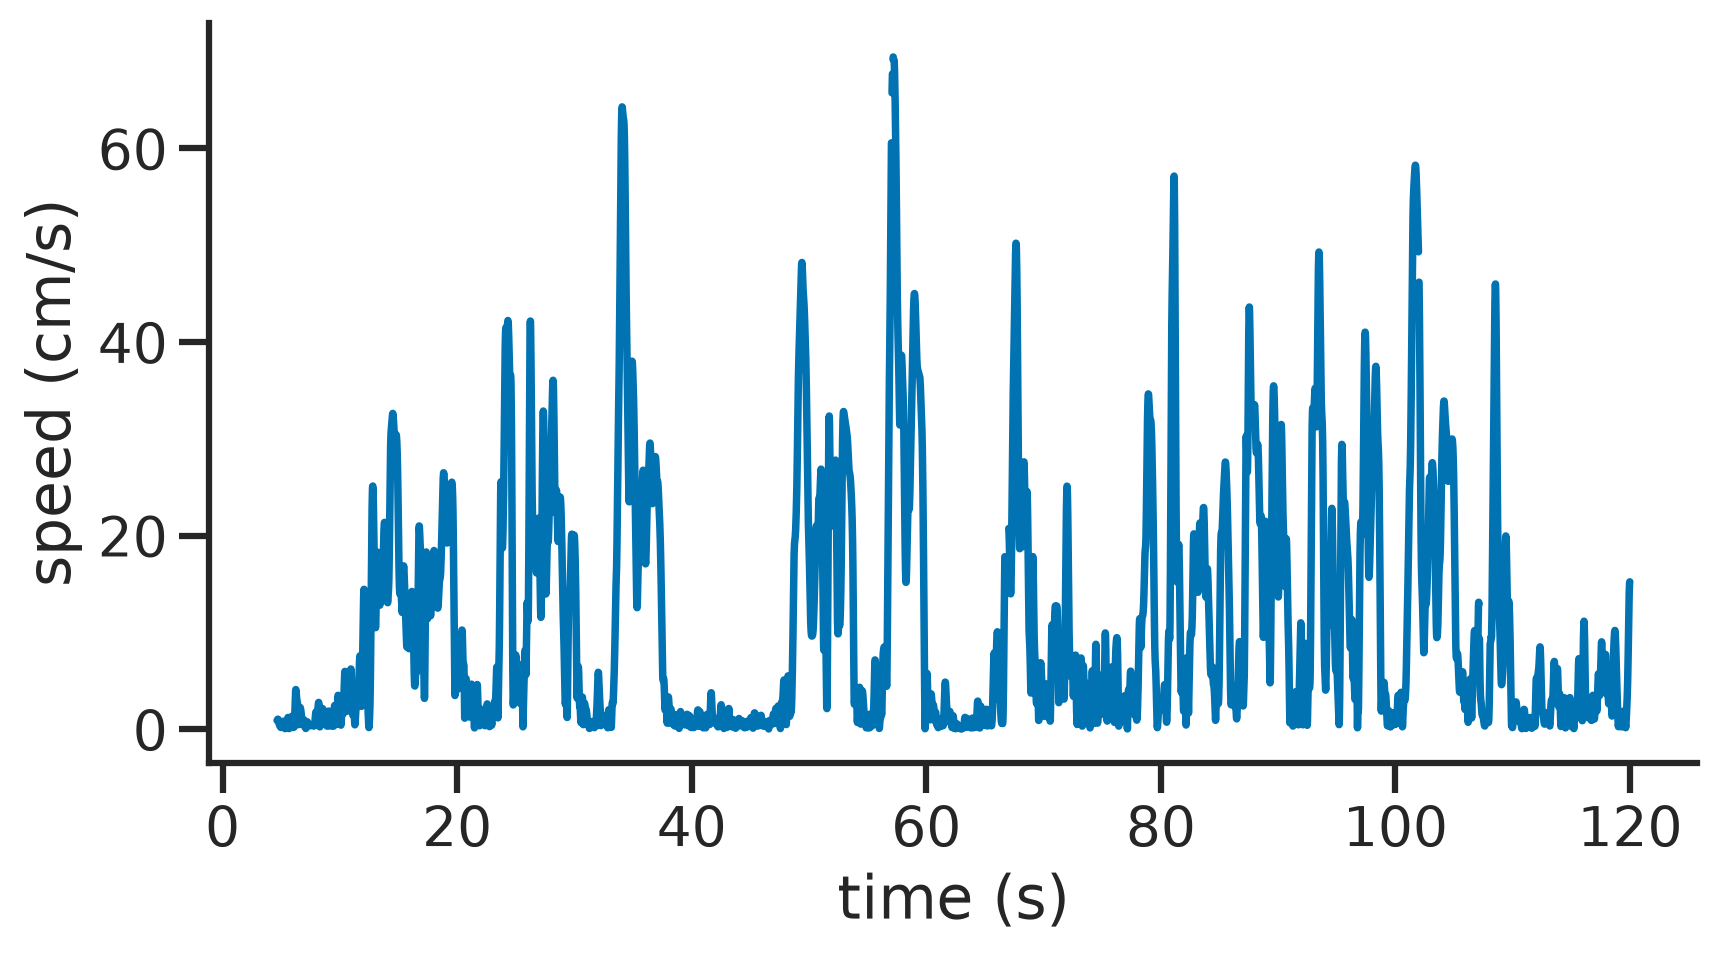

In [61]:
# Solution: compute and plot speed over time using position_df

dx = np.diff(position_df["x"].to_numpy())
dy = np.diff(position_df["y"].to_numpy())
distance = np.sqrt(dx**2 + dy**2)

dt = np.diff(position_df["time"].to_numpy())

speed = distance / dt

# Pair each speed value with the midpoint time of the interval it describes.
speed_time = position_df["time"].to_numpy()[:-1] + dt / 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(speed_time, speed)
ax.set_xlabel("time (s)")
ax.set_ylabel("speed (cm/s)")

## 4. Explore Units

Each row of `nwb.units` is one sorted neuron: its spike times plus the electrode(s) it was recorded on. Pair that with the electrode table's `location` column to label every unit with a brain area, and build a single DataFrame to explore from.

In [62]:
electrodes_df = nwb.electrodes.to_dataframe()

def lookup_region(unit_electrodes):
    """Look up the brain-area label for a unit's (first) recording electrode."""
    first_electrode_id = unit_electrodes.index[0]
    return electrodes_df.loc[first_electrode_id, "location"]

units_df = nwb.units.to_dataframe()
units_df["region"] = units_df["electrodes"].apply(lookup_region)
units_df["n_spikes"] = units_df["spike_times"].apply(len)

display(units_df[["region", "n_spikes"]].head(20))
print(f"{len(units_df):,} units total")
print(units_df["region"].value_counts())

,region,n_spikes
id,,
0,CA3,129
1,CA3,144
2,CA3,370
3,CA3,167
4,CA3,139
5,CA3,126
6,CA3,159
7,DG-sg,158
8,DG-sg,184


341 units total
region
CA1         98
cing        69
ccb         37
DG-sg       28
CA3         25
DG-mo       23
RSPd6a      18
RSPagl6a    17
DG-po       13
alv          8
SSp-tr6b     2
RSPd6b       2
RSPagl6b     1
Name: count, dtype: int64


### Raster Plot of All Units

A raster plot shows every unit's spikes as short tick marks along a shared time axis, one row per unit. It's the fastest way to see population-level activity: bursts, silence, and rhythmicity all become visible at a glance.

Set `raster_start_time` and `raster_stop_time` at the top of the cell below to the window you want to look at. The cell also prints every region name found in this session — type the region name(s) you want into `regions_to_plot`, exactly as printed, then rerun.

Available regions:
  - CA1
  - CA3
  - DG-mo
  - DG-po
  - DG-sg
  - RSPagl6a
  - RSPagl6b
  - RSPd6a
  - RSPd6b
  - SSp-tr6b
  - alv
  - ccb
  - cing


Text(0, 0.5, 'unit index')

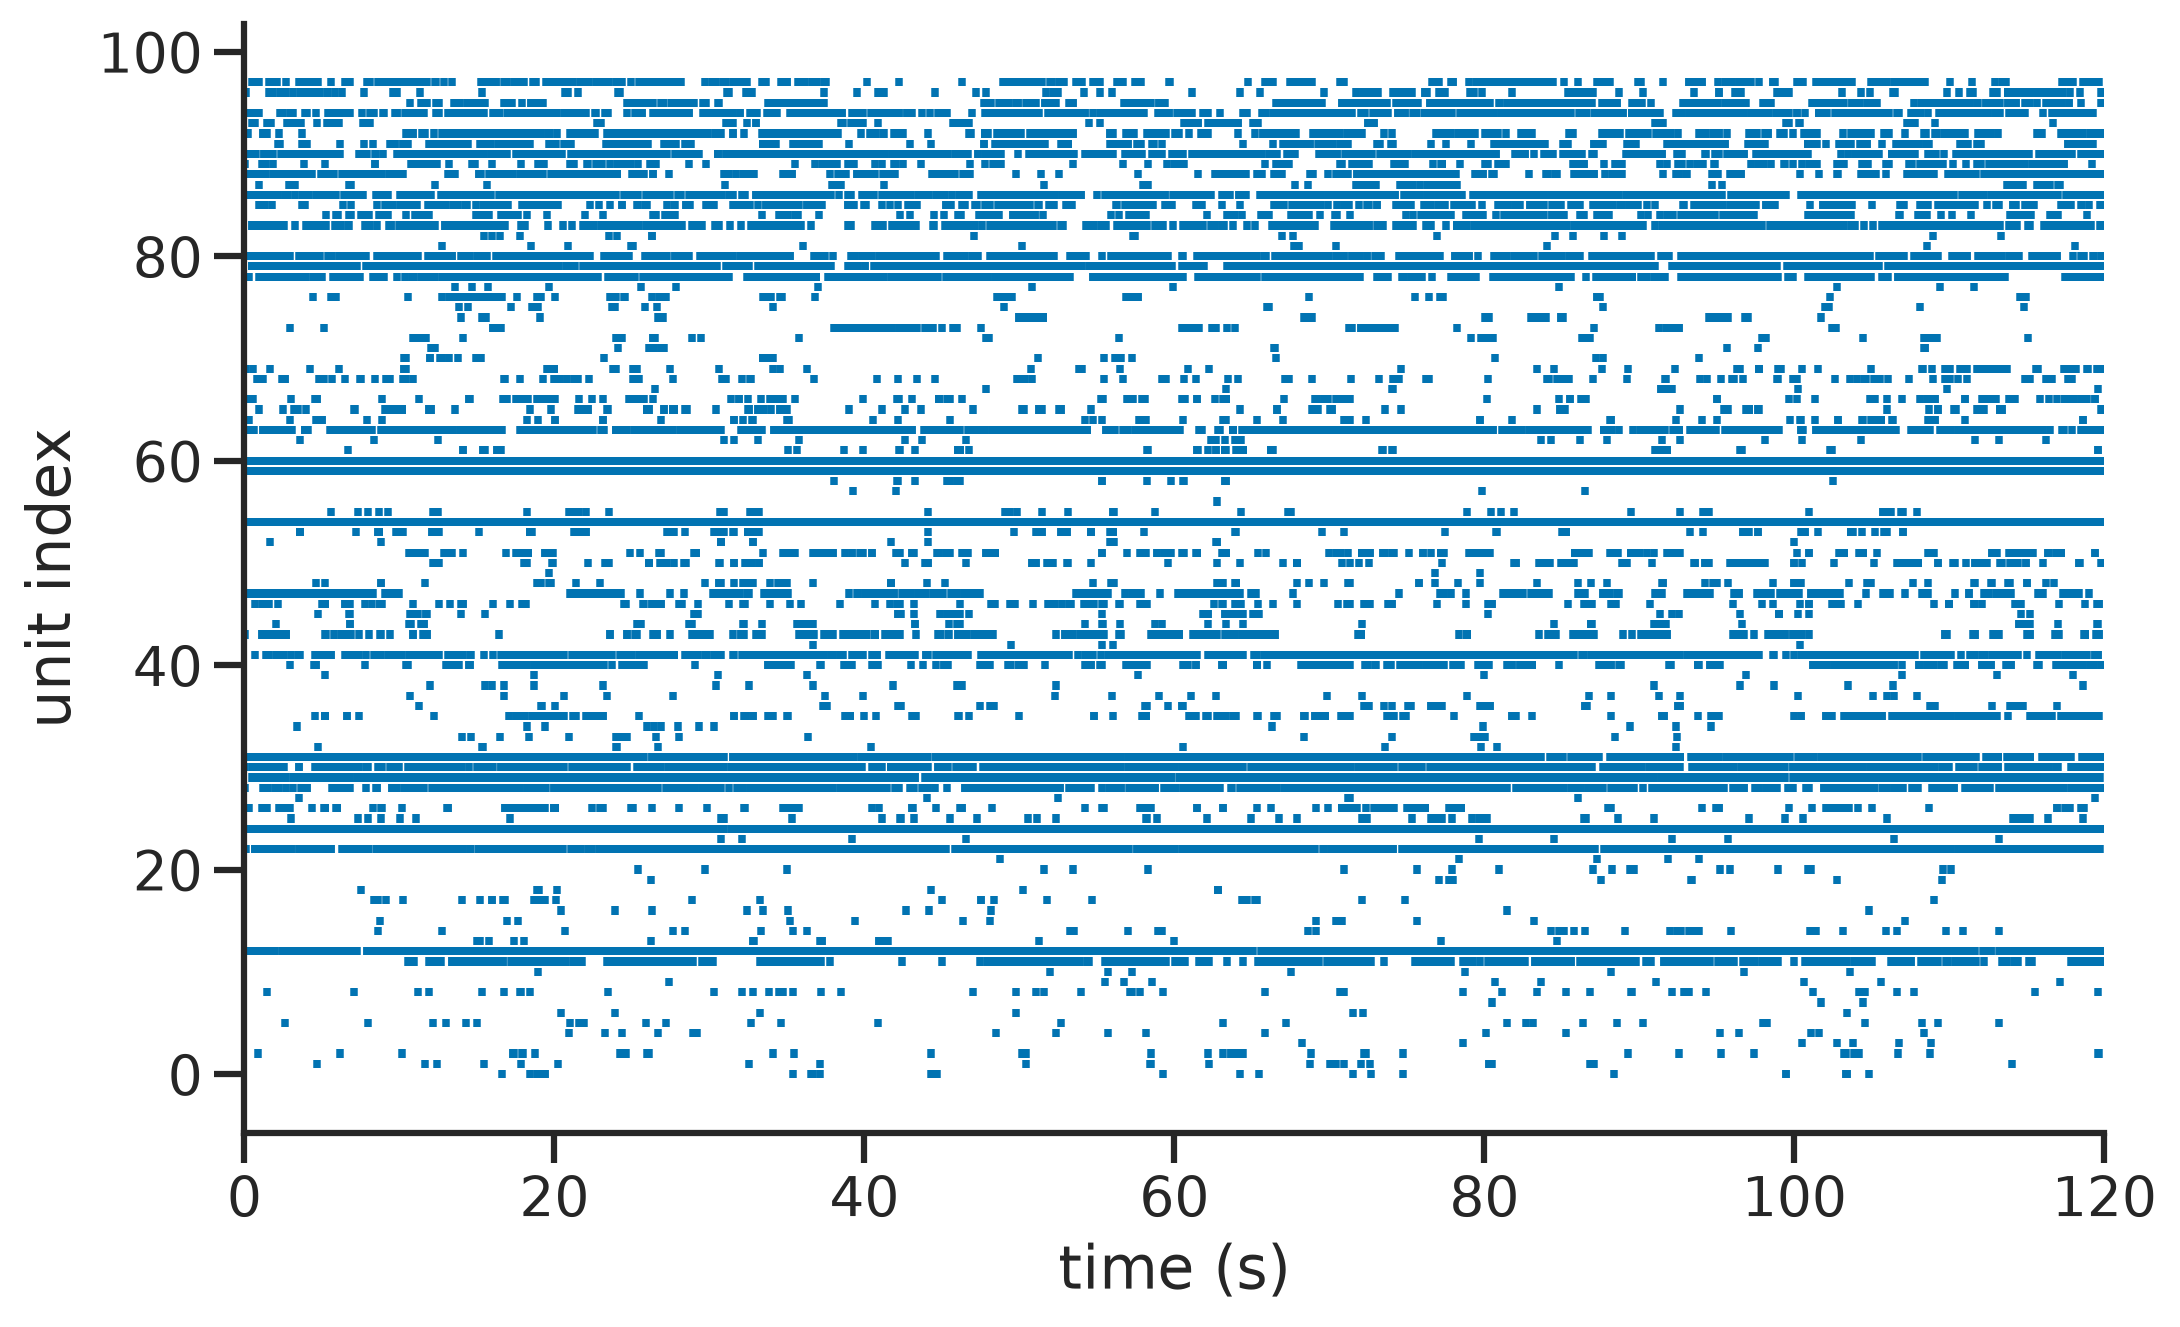

In [64]:
raster_start_time = 0.0
raster_stop_time = 120.0

print("Available regions:")
for region in sorted(units_df["region"].unique()):
    print(f"  - {region}")

# Type the region name(s) you want to plot, exactly as printed above.
regions_to_plot = ["CA1"]

subset = units_df[units_df["region"].isin(regions_to_plot)]

spikes_in_window = []
for spike_times in subset["spike_times"]:
    spike_times = np.asarray(spike_times)
    in_window = (spike_times >= raster_start_time) & (spike_times <= raster_stop_time)
    spikes_in_window.append(spike_times[in_window])

fig, ax = plt.subplots(figsize=(10, 6))
ax.eventplot(spikes_in_window, linelengths=0.8)
ax.set_xlim(raster_start_time, raster_stop_time)
ax.set_xlabel("time (s)")
ax.set_ylabel("unit index")

### Where Does a Unit Spike?

Now zoom in on a single neuron: for every spike it fired, where was the animal standing? Plot those spike locations on top of the full trajectory to see whether the neuron prefers particular parts of the environment.

The cell below prints the ids and spike counts of the units in `regions_to_plot` from above. Type one of those ids into `unit_id`, then rerun.

In [80]:
print("Units available in the selected region(s):")
display(subset[["region", "n_spikes"]].head(20))

Units available in the selected region(s):


,region,n_spikes
id,,
13,CA1,194
14,CA1,151
15,CA1,176
16,CA1,149
17,CA1,344
18,CA1,457
21,CA1,204
22,CA1,175
23,CA1,887


In [83]:
# Type the id of the unit you want to plot, from the table above.
unit_id = 44

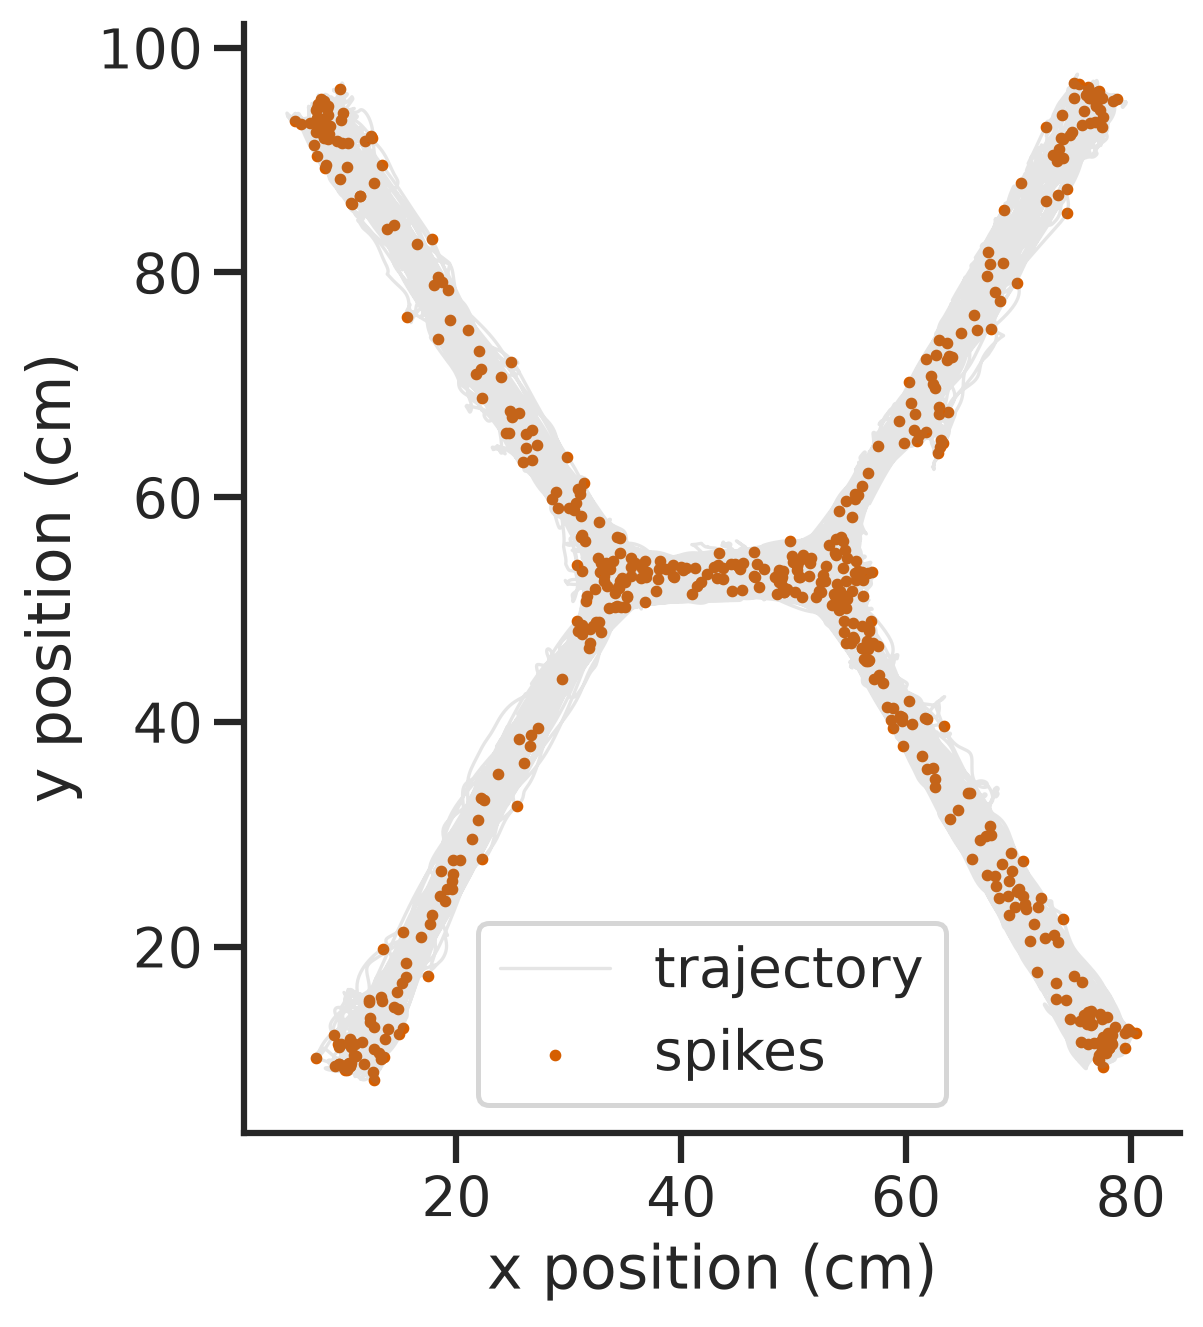

In [84]:
spike_times = np.asarray(subset.loc[unit_id, "spike_times"])

# For each spike, find the position sample recorded closest in time (full recording).
nearest_index = np.searchsorted(time, spike_times)
nearest_index = np.clip(nearest_index, 0, len(time) - 1)

spike_x = position_data[nearest_index, 0]
spike_y = position_data[nearest_index, 1]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(position_data[:, 0], position_data[:, 1], color="grey", alpha=0.2, linewidth=1, label="trajectory")
ax.scatter(spike_x, spike_y, color=COLORS["red"], s=4, label="spikes")

ax.set_xlabel("x position (cm)")
ax.set_ylabel("y position (cm)")
ax.set_aspect("equal")
ax.legend()

### Occupancy and Firing Rate Maps

The spike-location scatter above is a start, but it doesn't account for the animal spending more time in some parts of the environment than others — a neuron could look "active" somewhere simply because the animal lingered there. To correct for this, divide a grid over the environment and compute two maps:

1. **Occupancy**: how much time the animal spent in each spatial bin.
2. **Firing rate**: spikes per bin divided by occupancy time in that bin, giving spikes/second regardless of how long the animal spent there.

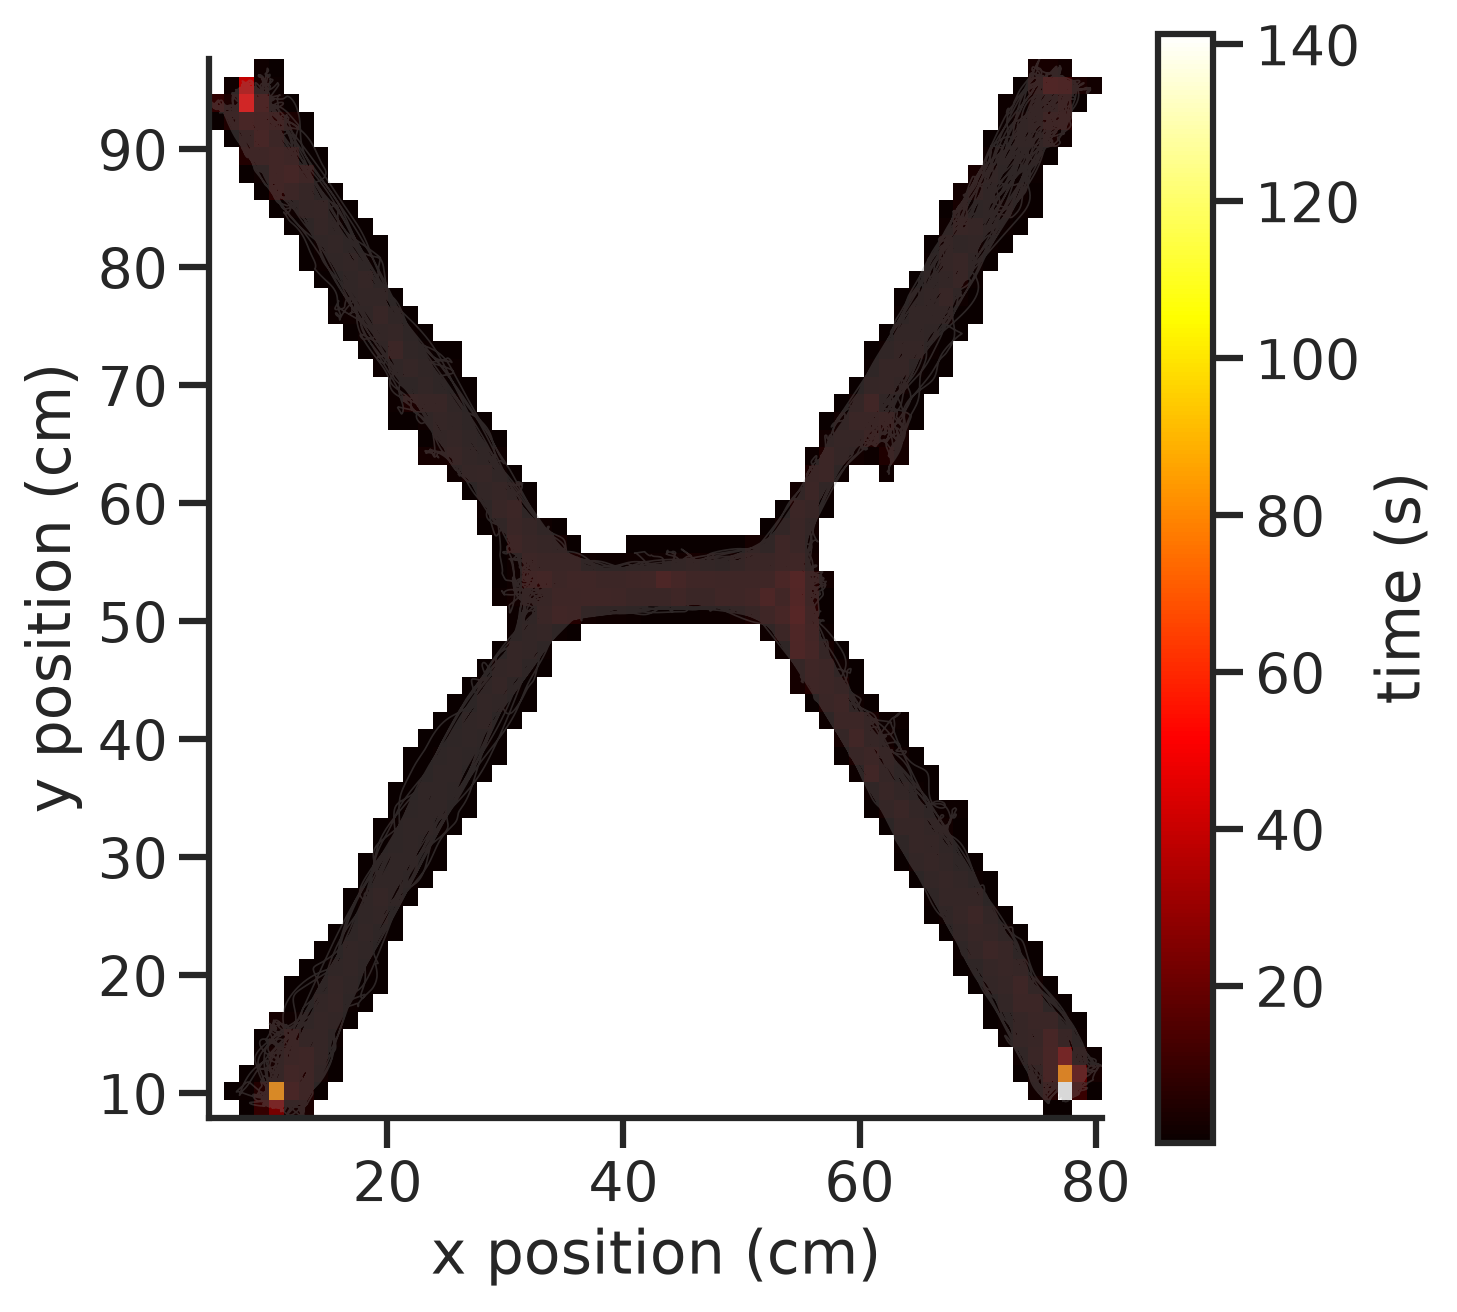

In [ ]:
n_bins = 60

valid = ~np.isnan(position_data[:, 0]) & ~np.isnan(position_data[:, 1])
valid_position = position_data[valid]

x_edges = np.linspace(valid_position[:, 0].min(), valid_position[:, 0].max(), n_bins + 1)
y_edges = np.linspace(valid_position[:, 1].min(), valid_position[:, 1].max(), n_bins + 1)

occupancy_counts, _, _ = np.histogram2d(valid_position[:, 0], valid_position[:, 1], bins=[x_edges, y_edges])
occupancy_time = occupancy_counts / sampling_rate

occupancy_cmap = plt.cm.hot.copy()
occupancy_cmap.set_bad(alpha=0)
occupancy_masked = np.ma.masked_equal(occupancy_time, 0)sa

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(valid_position[:, 0], valid_position[:, 1], color="grey", alpha=0.3, linewidth=0.5)
im = ax.imshow(
    occupancy_masked.T,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="equal",
    cmap=occupancy_cmap,
)
ax.set_xlabel("x position (cm)")
ax.set_ylabel("y position (cm)")
fig.colorbar(im, ax=ax, label="time (s)")

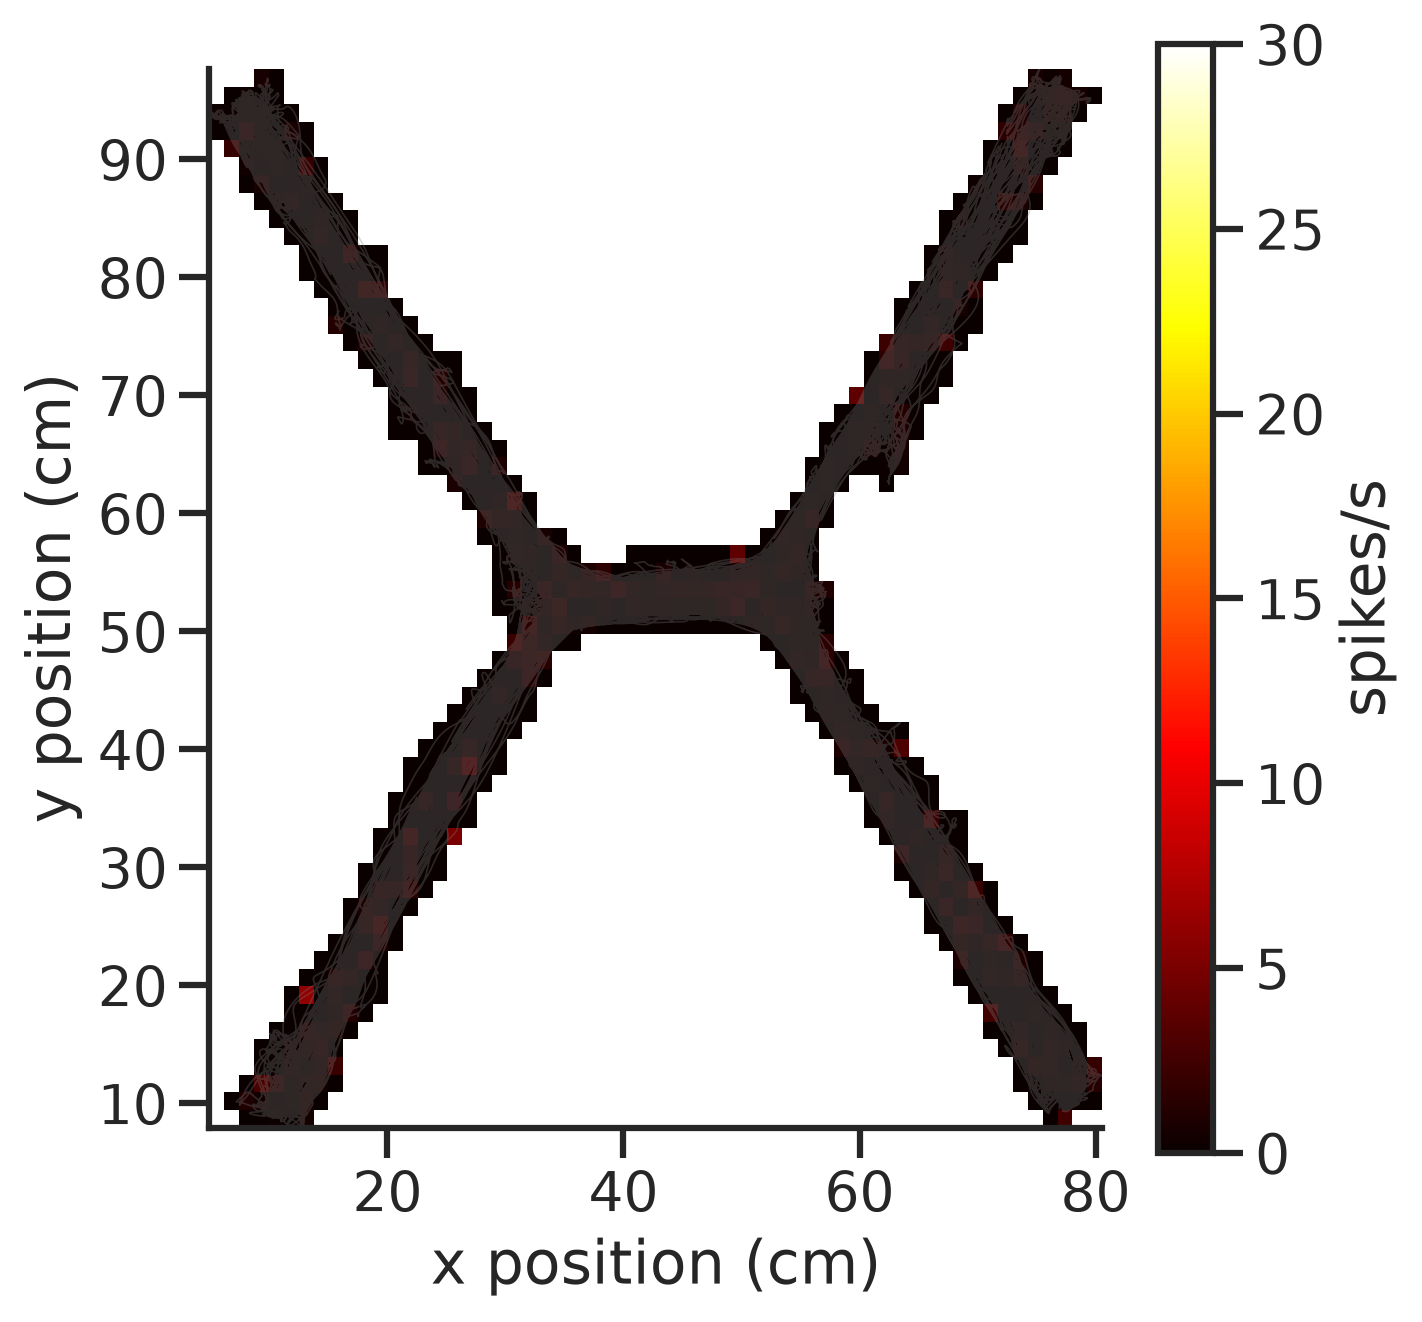

In [86]:
spike_counts, _, _ = np.histogram2d(spike_x, spike_y, bins=[x_edges, y_edges])

with np.errstate(invalid="ignore", divide="ignore"):
    firing_rate = spike_counts / occupancy_time
firing_rate[occupancy_time == 0] = np.nan

firing_rate_cmap = plt.cm.hot.copy()
firing_rate_cmap.set_bad(alpha=0)
firing_rate_masked = np.ma.masked_invalid(firing_rate)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(position_data[:, 0], position_data[:, 1], color="grey", alpha=0.3, linewidth=0.5)
im = ax.imshow(
    firing_rate_masked.T,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    aspect="equal",
    cmap=firing_rate_cmap,
)
ax.set_xlabel("x position (cm)")
ax.set_ylabel("y position (cm)")
fig.colorbar(im, ax=ax, label="spikes/s")